In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv("../data/processed/oews_all_occupations_2015_2025.csv")
df.head()

,soc_code,occupation_title,year,employment,median_wage,mean_wage,wage_pct10,wage_pct25,wage_pct75,wage_pct90
0,11-1011,Chief Executives,2020,202360.0,185950.0,197840.0,62780.0,114530.0,NaN,NaN
1,11-1021,General and Operations Managers,2020,2347420.0,103650.0,125740.0,45850.0,67450.0,161190.0,NaN
2,11-1031,Legislators,2020,51290.0,33200.0,53560.0,18120.0,19790.0,83780.0,105100.0
3,11-2011,Advertising and Promotions Managers,2020,22490.0,133460.0,147560.0,68940.0,91910.0,181800.0,NaN
4,11-2021,Marketing Managers,2020,270200.0,142170.0,154470.0,74620.0,101690.0,191760.0,NaN


In [2]:

df_2020 = df[df["year"] == 2020][["soc_code","occupation_title","employment"]]
df_2025 = df[df["year"] == 2025][["soc_code","occupation_title","employment"]]

growth = df_2020.merge(df_2025, on="soc_code", suffixes=("_2020","_2025"))
growth.head()

,soc_code,occupation_title_2020,employment_2020,occupation_title_2025,employment_2025
0,11-1011,Chief Executives,202360.0,Chief Executives,204350.0
1,11-1021,General and Operations Managers,2347420.0,General and Operations Managers,3503020.0
2,11-2011,Advertising and Promotions Managers,22490.0,Advertising and Promotions Managers,21470.0
3,11-2021,Marketing Managers,270200.0,Marketing Managers,395240.0
4,11-2022,Sales Managers,390170.0,Sales Managers,637080.0


In [3]:
print(df.dtypes)

soc_code             object
occupation_title     object
year                  int64
employment          float64
median_wage         float64
mean_wage           float64
wage_pct10          float64
wage_pct25          float64
wage_pct75          float64
wage_pct90          float64
dtype: object


In [4]:
non_numeric_employment = df[pd.to_numeric(df["employment"], errors="coerce").isna() & df["employment"].notna()]
non_numeric_employment[["soc_code", "occupation_title", "year", "employment"]]

,soc_code,occupation_title,year,employment


In [5]:
growth["employment_change"] = growth["employment_2025"] - growth["employment_2020"]
growth["percentage_change"]= (growth["employment_change"] / growth["employment_2020"]) * 100

In [6]:
growth.sort_values("percentage_change", ascending=False).head(10)

,soc_code,occupation_title_2020,employment_2020,occupation_title_2025,employment_2025,employment_change,percentage_change
361,35-2013,"Cooks, Private Household",320.0,"Cooks, Private Household",1100.0,780.0,243.750000
531,47-2231,Solar Photovoltaic Installers,11490.0,Solar Photovoltaic Installers,31350.0,19860.0,172.845953
402,39-5092,Manicurists and Pedicurists,73010.0,Manicurists and Pedicurists,152770.0,79760.0,109.245309
357,35-1011,Chefs and Head Cooks,101490.0,Chefs and Head Cooks,200040.0,98550.0,97.103163
288,29-1129,"Therapists, All Other",11710.0,"Therapists, All Other",22640.0,10930.0,93.339026
310,29-2053,Psychiatric Technicians,85330.0,Psychiatric Technicians,156960.0,71630.0,83.944685
395,39-3099,"Entertainment Attendants and Related Workers, ...",3900.0,"Entertainment Attendants and Related Workers, ...",7060.0,3160.0,81.025641
248,27-2021,Athletes and Sports Competitors,8380.0,Athletes and Sports Competitors,15070.0,6690.0,79.832936
162,21-2099,"Religious Workers, All Other",8900.0,"Religious Workers, All Other",15760.0,6860.0,77.078652
599,49-9081,Wind Turbine Service Technicians,5860.0,Wind Turbine Service Technicians,9980.0,4120.0,70.307167


In [7]:
growth.sort_values("percentage_change", ascending=True).head(10)

,soc_code,occupation_title_2020,employment_2020,occupation_title_2025,employment_2025,employment_change,percentage_change
615,51-2061,Timing Device Assemblers and Adjusters,1000.0,Timing Device Assemblers and Adjusters,250.0,-750.0,-75.000000
432,41-9091,"Door-to-Door Sales Workers, News and Street Ve...",8360.0,"Door-to-Door Sales Workers, News and Street Ve...",2760.0,-5600.0,-66.985646
669,51-7031,"Model Makers, Wood",800.0,"Model Makers, Wood",280.0,-520.0,-65.000000
437,43-2099,"Communications Equipment Operators, All Other",3070.0,"Communications Equipment Operators, All Other",1200.0,-1870.0,-60.912052
511,47-2053,Terrazzo Workers and Finishers,2970.0,Terrazzo Workers and Finishers,1180.0,-1790.0,-60.269360
686,51-9022,"Grinding and Polishing Workers, Hand",24050.0,"Grinding and Polishing Workers, Hand",10510.0,-13540.0,-56.299376
500,45-4029,"Logging Workers, All Other",3850.0,"Logging Workers, All Other",1700.0,-2150.0,-55.844156
480,43-9031,Desktop Publishers,7090.0,Desktop Publishers,3350.0,-3740.0,-52.750353
449,43-4041,"Credit Authorizers, Checkers, and Clerks",24600.0,"Credit Authorizers, Checkers, and Clerks",12030.0,-12570.0,-51.097561
431,41-9041,Telemarketers,117610.0,Telemarketers,58430.0,-59180.0,-50.318850


In [8]:
top_growth_codes = growth.sort_values("percentage_change", ascending=False).head(5)["soc_code"]

trend_data = df[df["soc_code"].isin(top_growth_codes)]
trend_data = trend_data[["soc_code", "occupation_title", "year", "employment"]]
trend_data.sort_values(["soc_code", "year"])

,soc_code,occupation_title,year,employment
305,29-1129,"Therapists, All Other",2020,11710.0
1112,29-1129,"Therapists, All Other",2021,13490.0
1942,29-1129,"Therapists, All Other",2022,16920.0
2773,29-1129,"Therapists, All Other",2023,16490.0
3604,29-1129,"Therapists, All Other",2024,19320.0
4434,29-1129,"Therapists, All Other",2025,22640.0
382,35-1011,Chefs and Head Cooks,2020,101490.0
1206,35-1011,Chefs and Head Cooks,2021,129810.0
2036,35-1011,Chefs and Head Cooks,2022,160190.0
2867,35-1011,Chefs and Head Cooks,2023,172370.0


In [9]:
growth[growth["occupation_title_2020"] == "Data Scientists"]

,soc_code,occupation_title_2020,employment_2020,occupation_title_2025,employment_2025,employment_change,percentage_change


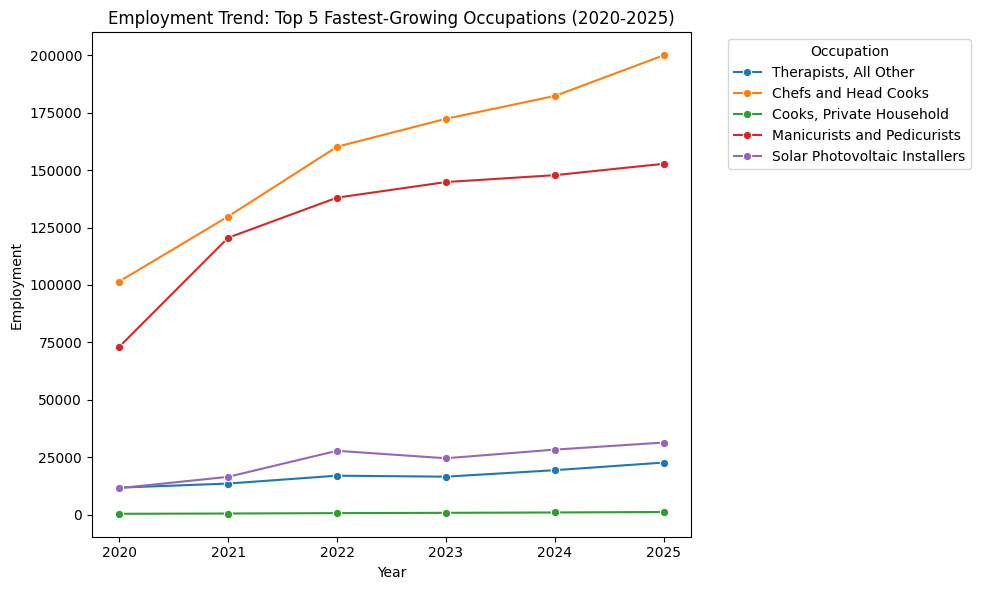

In [10]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=trend_data, x="year", y="employment", hue="occupation_title", marker="o")

plt.title("Employment Trend: Top 5 Fastest-Growing Occupations (2020-2025)")
plt.xlabel("Year")
plt.ylabel("Employment")
plt.legend(title="Occupation", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [11]:
growth.to_csv("../data/processed/occupation_growth_2020_2025.csv", index=False)
print("Saved.")

Saved.


In [20]:
onet_skills = pd.read_csv("../data/processed/onet_skills.csv")
master = pd.read_csv("../data/processed/master_ocupations.csv")

skill_wage = onet_skills.merge(master[["occupation_title", "median_wage"]], on="occupation_title")
skill_wage.head()

,occupation_title,soc_code_clean,skill_name,importance_score,median_wage
0,Human Resources Specialists,13-1071,Reading Comprehension,4.00,75940
1,Human Resources Specialists,13-1071,Active Listening,4.00,75940
2,Human Resources Specialists,13-1071,Writing,3.88,75940
3,Human Resources Specialists,13-1071,Speaking,4.12,75940
4,Human Resources Specialists,13-1071,Mathematics,2.00,75940


In [21]:
skill_avg_wage = skill_wage.groupby("skill_name")["median_wage"].mean().sort_values(ascending=False)
print(skill_avg_wage.head(15))

skill_name
Active Learning          77230.0
Active Listening         77230.0
Critical Thinking        77230.0
Learning Strategies      77230.0
Mathematics              77230.0
Monitoring               77230.0
Reading Comprehension    77230.0
Science                  77230.0
Speaking                 77230.0
Writing                  77230.0
Name: median_wage, dtype: float64


In [24]:
skill_occupation_counts = skill_wage.groupby("skill_name")["occupation_title"].nunique().sort_values(ascending=False)
print(skill_occupation_counts.head(15))


skill_name
Active Learning          10
Active Listening         10
Critical Thinking        10
Learning Strategies      10
Mathematics              10
Monitoring               10
Reading Comprehension    10
Science                  10
Speaking                 10
Writing                  10
Name: occupation_title, dtype: int64


In [26]:
correlation_by_skill = skill_wage.groupby("skill_name").apply(
    lambda group: group["importance_score"].corr(group["median_wage"])
).sort_values(ascending=False)

print(correlation_by_skill)

skill_name
Critical Thinking        0.817206
Science                  0.785919
Active Learning          0.734498
Mathematics              0.614079
Reading Comprehension    0.484195
Writing                  0.461060
Learning Strategies      0.428822
Monitoring               0.238032
Speaking                 0.005681
Active Listening        -0.066660
dtype: float64


C:\Users\aditya bhoite\AppData\Local\Temp\ipykernel_17332\832232955.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_by_skill = skill_wage.groupby("skill_name").apply(


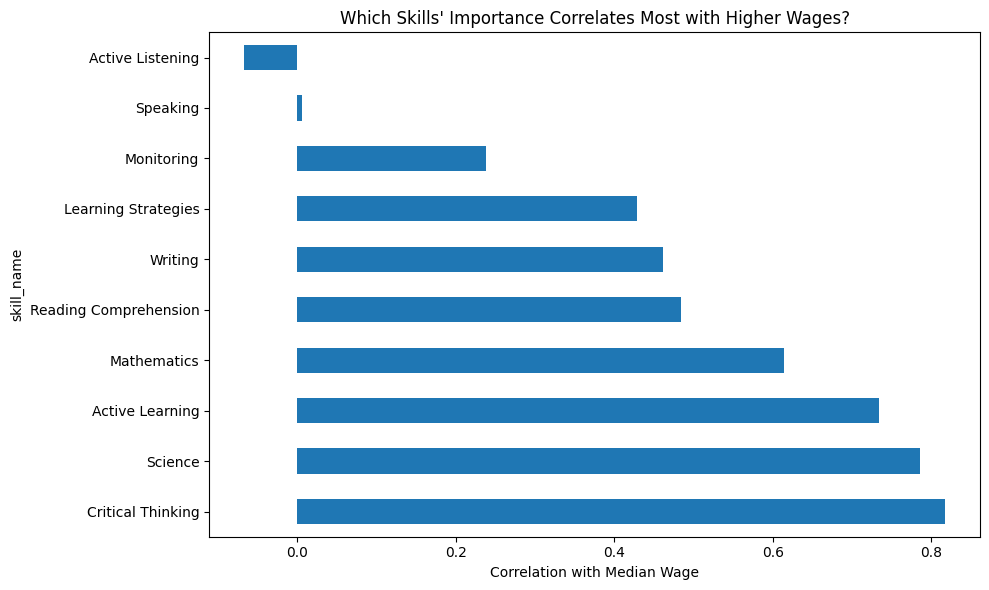

In [27]:
plt.figure(figsize=(10, 6))
correlation_by_skill.plot(kind="barh")
plt.xlabel("Correlation with Median Wage")
plt.title("Which Skills' Importance Correlates Most with Higher Wages?")
plt.tight_layout()
plt.show()

In [28]:
full_skill_wage = pd.read_csv("../data/processed/full_skill_wage_analysis.csv")

correlation_by_skill_full = full_skill_wage.groupby("skill_name").apply(
    lambda group: group["importance_score"].corr(group["median_wage"])
).sort_values(ascending=False)

print(correlation_by_skill_full)

skill_name
Critical Thinking        0.630152
Active Learning          0.574558
Reading Comprehension    0.550427
Science                  0.546319
Writing                  0.537283
Monitoring               0.490333
Active Listening         0.487453
Speaking                 0.453590
Learning Strategies      0.434041
Mathematics              0.395798
dtype: float64


C:\Users\aditya bhoite\AppData\Local\Temp\ipykernel_17332\563154910.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_by_skill_full = full_skill_wage.groupby("skill_name").apply(


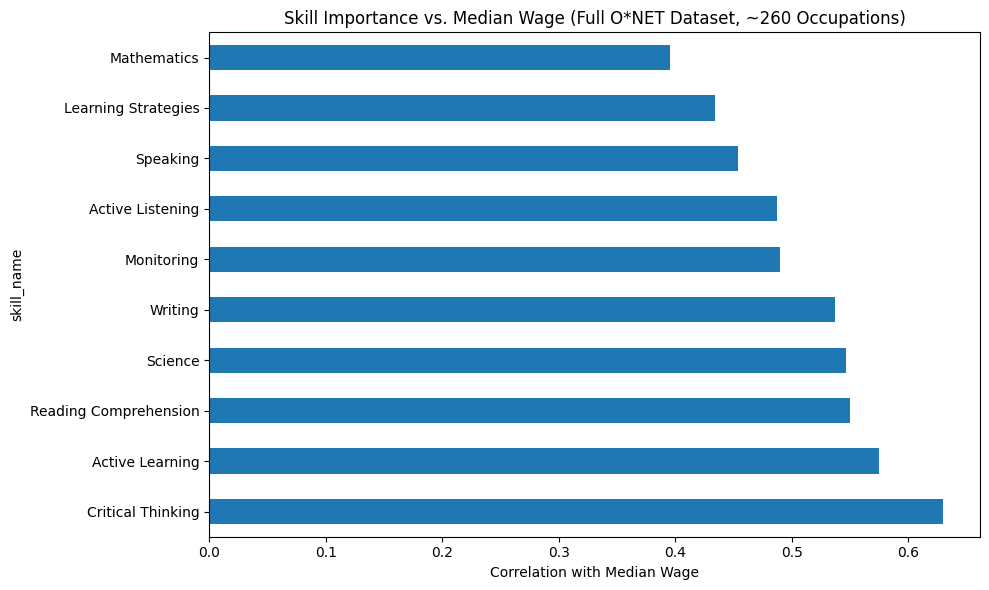

In [29]:
plt.figure(figsize=(10, 6))
correlation_by_skill_full.plot(kind="barh")
plt.xlabel("Correlation with Median Wage")
plt.title("Skill Importance vs. Median Wage (Full O*NET Dataset, ~260 Occupations)")
plt.tight_layout()
plt.show()

In [30]:
ces = pd.read_csv("../data/processed/ces_industry_employment.csv")
ces.head()

,industry,series_id,year,period,employment_thousands
0,Total Nonfarm,CES0000000001,2024,December,158316
1,Total Nonfarm,CES0000000001,2024,November,158079
2,Total Nonfarm,CES0000000001,2024,October,157945
3,Total Nonfarm,CES0000000001,2024,September,157912
4,Total Nonfarm,CES0000000001,2024,August,157757


In [32]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

ces["period"] = pd.Categorical(ces["period"], categories=month_order, ordered=True)
ces["year_month"] = ces["year"].astype(str) + "-" + ces["period"].astype(str)

ces_sorted = ces.sort_values(["year", "period"])

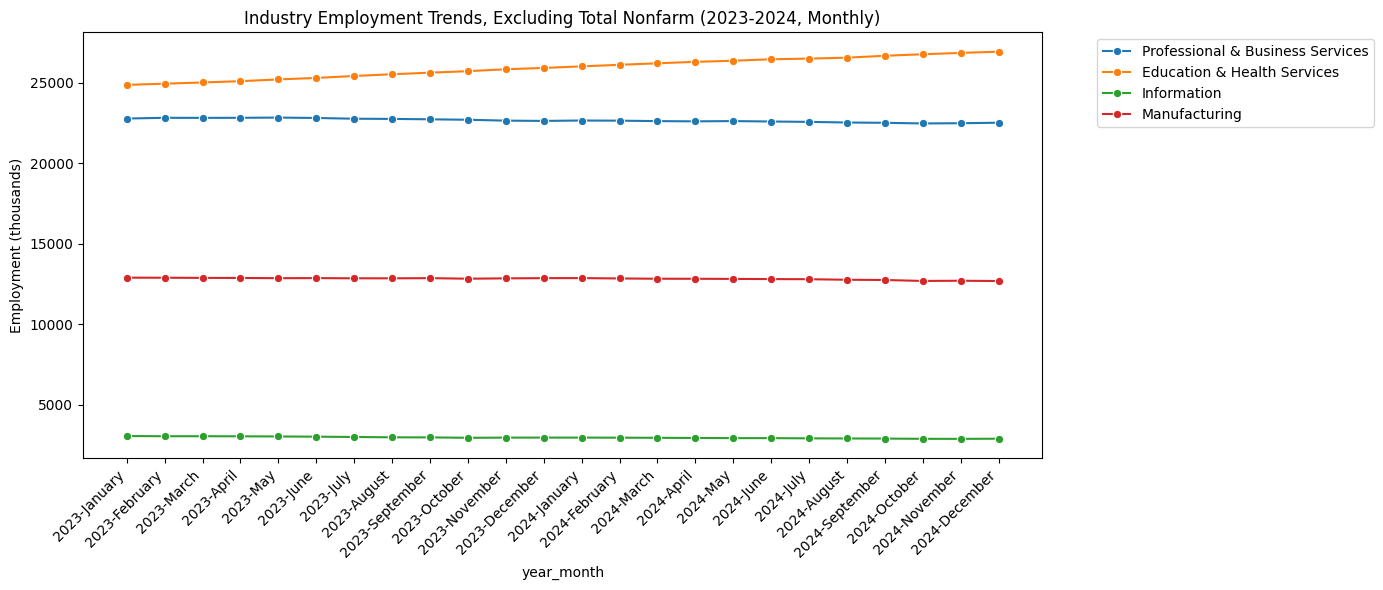

In [34]:
ces_industries_only = ces_sorted[ces_sorted["industry"] != "Total Nonfarm"]

plt.figure(figsize=(14, 6))
sns.lineplot(data=ces_industries_only, x="year_month", y="employment_thousands", hue="industry", marker="o")
plt.xticks(rotation=45, ha="right")
plt.title("Industry Employment Trends, Excluding Total Nonfarm (2023-2024, Monthly)")
plt.ylabel("Employment (thousands)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [35]:
ces_industries_only.to_csv("../data/processed/ces_industry_trends_clean.csv", index=False)
print("Saved.")

Saved.


In [36]:
laus = pd.read_csv("../data/processed/laus_state_unemployment.csv")
laus.head()

,state,series_id,year,period,unemployment_rate
0,California,LASST060000000000003,2024,December,5.4
1,California,LASST060000000000003,2024,November,5.4
2,California,LASST060000000000003,2024,October,5.4
3,California,LASST060000000000003,2024,September,5.4
4,California,LASST060000000000003,2024,August,5.4


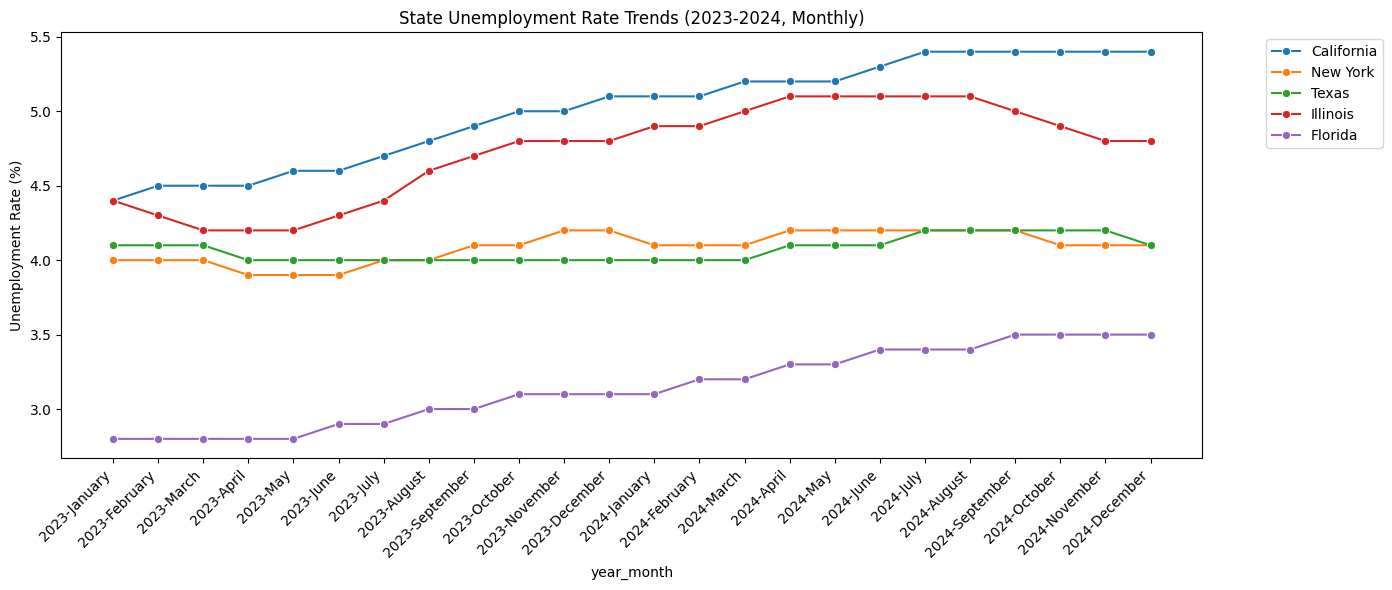

In [37]:
laus["period"] = pd.Categorical(laus["period"], categories=month_order, ordered=True)
laus["year_month"] = laus["year"].astype(str) + "-" + laus["period"].astype(str)
laus_sorted = laus.sort_values(["year", "period"])

plt.figure(figsize=(14, 6))
sns.lineplot(data=laus_sorted, x="year_month", y="unemployment_rate", hue="state", marker="o")
plt.xticks(rotation=45, ha="right")
plt.title("State Unemployment Rate Trends (2023-2024, Monthly)")
plt.ylabel("Unemployment Rate (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [38]:
laus_sorted.to_csv("../data/processed/laus_state_trends_clean.csv", index=False)
print("Saved.")

Saved.


In [40]:
full_skill_wage = pd.read_csv("../data/processed/full_skill_wage_analysis.csv")
print(full_skill_wage["skill_name"].unique())

['Reading Comprehension' 'Active Listening' 'Writing' 'Speaking'
 'Mathematics' 'Science' 'Critical Thinking' 'Active Learning'
 'Learning Strategies' 'Monitoring']


In [49]:
knowledge_raw = pd.read_csv("../data/raw/onet/db_31_0_csv/knowledge.csv")
print(knowledge_raw["Element Name"].unique())

['Administration and Management' 'Administrative'
 'Economics and Accounting' 'Sales and Marketing'
 'Customer and Personal Service' 'Personnel and Human Resources'
 'Production and Processing' 'Food Production' 'Computers and Electronics'
 'Engineering and Technology' 'Design' 'Building and Construction'
 'Mechanical' 'Mathematics' 'Physics' 'Chemistry' 'Biology' 'Psychology'
 'Sociology and Anthropology' 'Geography' 'Medicine and Dentistry'
 'Therapy and Counseling' 'Education and Training' 'English Language'
 'Foreign Language' 'Fine Arts' 'History and Archeology'
 'Philosophy and Theology' 'Public Safety and Security'
 'Law and Government' 'Telecommunications' 'Communications and Media'
 'Transportation']


In [53]:
knowledge_importance = knowledge_raw[knowledge_raw["Scale Name"] == "Importance"]

knowledge_clean = knowledge_importance[["O*NET-SOC Code", "Title", "Element Name", "Data Value"]]
knowledge_clean = knowledge_clean.rename(columns={
    "Title": "occupation_title",
    "Element Name": "knowledge_area",
    "Data Value": "importance_score"
})

knowledge_clean["soc_code_clean"] = knowledge_clean["O*NET-SOC Code"].str.split(".", regex=False).str[0]

print(knowledge_clean.head())

  O*NET-SOC Code  occupation_title                 knowledge_area  \
0     11-1011.00  Chief Executives  Administration and Management   
2     11-1011.00  Chief Executives                 Administrative   
4     11-1011.00  Chief Executives       Economics and Accounting   
6     11-1011.00  Chief Executives            Sales and Marketing   
8     11-1011.00  Chief Executives  Customer and Personal Service   

   importance_score soc_code_clean  
0              4.78        11-1011  
2              2.42        11-1011  
4              4.04        11-1011  
6              3.81        11-1011  
8              4.39        11-1011  


In [54]:
HIGH_EXPOSURE_AREAS = ["Computers and Electronics", "Administrative", "Economics and Accounting", "Mathematics"]
LOW_EXPOSURE_AREAS = ["Customer and Personal Service", "Therapy and Counseling", "Building and Construction", "Mechanical", "Public Safety and Security", "Transportation"]

high_exposure = knowledge_clean[knowledge_clean["knowledge_area"].isin(HIGH_EXPOSURE_AREAS)]
high_avg = high_exposure.groupby("soc_code_clean")["importance_score"].mean().rename("high_exposure_score")

low_exposure = knowledge_clean[knowledge_clean["knowledge_area"].isin(LOW_EXPOSURE_AREAS)]
low_avg = low_exposure.groupby("soc_code_clean")["importance_score"].mean().rename("low_exposure_score")

exposure_scores = pd.concat([high_avg, low_avg], axis=1).reset_index()
exposure_scores["ai_exposure_score"] = exposure_scores["high_exposure_score"] - exposure_scores["low_exposure_score"]

print(exposure_scores.head())


  soc_code_clean  high_exposure_score  low_exposure_score  ai_exposure_score
0        11-1011               3.2025            2.761667           0.440833
1        11-1021               3.1525            2.625000           0.527500
2        11-2011               3.4650            2.040000           1.425000
3        11-2021               2.9025            2.228333           0.674167
4        11-2022               2.8875            2.058333           0.829167


In [ ]:
oews_full = pd.read_csv("../data/processed/oews_all_occupations_2015_2025.csv")
oews_2025 = oews_full[oews_full["year"] == 2025]

exposure_with_titles = exposure_scores.merge(
    oews_2025[["soc_code", "occupation_title"]],
    left_on="soc_code_clean",
    right_on="soc_code",
    how="inner"
)

print("=== HIGHEST AI EXPOSURE ===")
print(exposure_with_titles.sort_values("ai_exposure_score", ascending=False)[["occupation_title", "ai_exposure_score"]].head(10))

print("\n=== LOWEST AI EXPOSURE ===")
print(exposure_with_titles.sort_values("ai_exposure_score", ascending=True)[["occupation_title", "ai_exposure_score"]].head(10))

=== HIGHEST AI EXPOSURE ===
                      occupation_title  ai_exposure_score
457     Payroll and Timekeeping Clerks           2.425000
79                           Actuaries           2.362500
139                         Economists           2.289167
499             Statistical Assistants           2.160000
54                     Budget Analysts           2.114167
55                     Credit Analysts           1.904167
198  Economics Teachers, Postsecondary           1.848333
62                       Tax Preparers           1.821667
10                  Financial Managers           1.811111
53            Accountants and Auditors           1.806667

=== LOWEST AI EXPOSURE ===
                                     occupation_title  ai_exposure_score
612  Manufactured Building and Mobile Home Installers          -1.452500
725                               Bus Drivers, School          -1.390000
743                              Passenger Attendants          -1.294167
509           

In [57]:
growth_full = df_2020.merge(df_2025, on="soc_code", suffixes=("_2020", "_2025"))
growth_full["pct_change"] = ((growth_full["employment_2025"] - growth_full["employment_2020"]) / growth_full["employment_2020"]) * 100

exposure_growth = exposure_scores.merge(growth_full, left_on="soc_code_clean", right_on="soc_code")

correlation = exposure_growth["ai_exposure_score"].corr(exposure_growth["pct_change"])
print(f"Correlation between AI exposure and employment growth: {correlation:.3f}")

Correlation between AI exposure and employment growth: 0.008


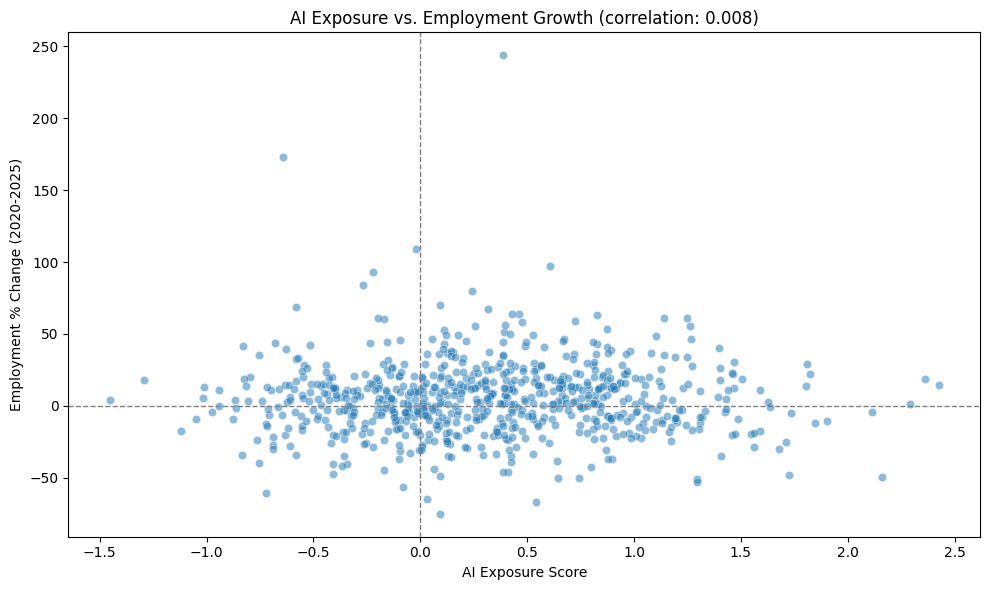

In [58]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=exposure_growth, x="ai_exposure_score", y="pct_change", alpha=0.5)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("AI Exposure Score")
plt.ylabel("Employment % Change (2020-2025)")
plt.title(f"AI Exposure vs. Employment Growth (correlation: {correlation:.3f})")
plt.tight_layout()
plt.show()

In [59]:
exposure_with_titles.to_csv("../data/processed/ai_exposure_scores.csv", index=False)
exposure_growth.to_csv("../data/processed/ai_exposure_vs_growth.csv", index=False)
print("Saved.")

Saved.
